In [39]:
# ==================== BOUNDARY CONFIGURATION ====================
EE_PROJECT = "fundamentals-of-remote-sensing"   # your Earth Engine Cloud project ID

BOUNDARIES_SHAPEFILE = "/Users/colelacroix/Downloads/Parks/Parks.shp"  # multi-feature boundary shapefile
SITE_NAME_FIELD = "NAME"                                               # attribute column holding site names
SITE_NAME = "Forest Park"                                              # which feature to run the inventory on

In [40]:
import ee

try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

print("Earth Engine initialized.")

Earth Engine initialized.


Boundary set to 'Forest Park': 10 polygon(s), 5,111.0 acres.


<Axes: >

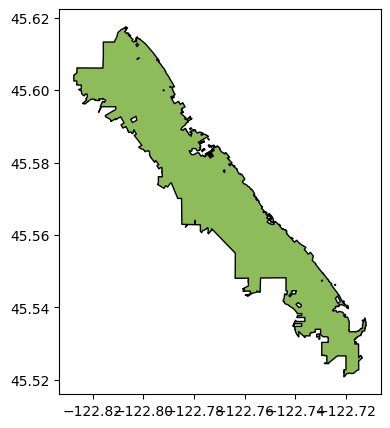

In [41]:
import geopandas as gpd
from shapely.geometry import mapping

def load_site_boundary(shapefile_path, name_field, site_name):
    """Load a multi-feature boundary shapefile and isolate one site by name."""
    sites_gdf = gpd.read_file(shapefile_path)

    match = sites_gdf[sites_gdf[name_field].str.strip().str.lower() == site_name.strip().lower()]
    if match.empty:
        match = sites_gdf[sites_gdf[name_field].str.contains(site_name, case=False, na=False)]
    if match.empty:
        available = sorted(sites_gdf[name_field].dropna().unique().tolist())
        raise ValueError(f"'{site_name}' not found in '{name_field}'. Available names: {available}")

    return match.to_crs(epsg=4326).dissolve().explode(index_parts=False).reset_index(drop=True)

boundary_gdf = load_site_boundary(BOUNDARIES_SHAPEFILE, SITE_NAME_FIELD, SITE_NAME)
boundary_area_acres = boundary_gdf.to_crs(epsg=5070).area.sum() / 4046.8564224
boundary_ee = ee.Geometry(mapping(boundary_gdf.union_all()))

print(f"Boundary set to '{SITE_NAME}': {len(boundary_gdf)} polygon(s), {boundary_area_acres:,.1f} acres.")
boundary_gdf.plot(edgecolor="black", facecolor="#8fbc5a", figsize=(5, 5))

In [42]:
# ==================== SEASONAL IMAGERY CONFIGURATION ====================
LEAFOFF_START_DATE = "2024-12-01"   # winter window (leaf-off) — same annual cycle as your summer window
LEAFOFF_END_DATE = "2025-02-28"

In [43]:
leafoff_s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(boundary_ee)
    .filterDate(LEAFOFF_START_DATE, LEAFOFF_END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD_PCT))
    .map(mask_s2_clouds)
)

n_leafoff_images = leafoff_s2.size().getInfo()
if n_leafoff_images == 0:
    raise RuntimeError(
        "No Sentinel-2 scenes found for the leaf-off window. Try widening "
        "LEAFOFF_START_DATE/LEAFOFF_END_DATE or raising MAX_CLOUD_PCT — "
        "winter imagery is sparser due to short days/cloud cover in the PNW."
    )

leafoff_composite = leafoff_s2.median().clip(boundary_ee)
leafoff_ndvi = leafoff_composite.normalizedDifference(["B8", "B4"]).rename("NDVI_leafoff")

print(f"Used {n_leafoff_images} leaf-off Sentinel-2 scene(s).")

Used 8 leaf-off Sentinel-2 scene(s).


In [44]:
seasonal_diff = ndvi.subtract(leafoff_ndvi).rename("seasonal_diff")

percentiles = [round(100 * i / NUM_STRATA) for i in range(1, NUM_STRATA)]
percentile_output_names = [f"p{p}" for p in percentiles]
quantiles = seasonal_diff.reduceRegion(
    reducer=ee.Reducer.percentile(percentiles, percentile_output_names),
    geometry=boundary_ee,
    scale=10,
    maxPixels=1e9,
    bestEffort=True,
).getInfo()

print(quantiles)
breaks = [quantiles[f"seasonal_diff_{name}"] for name in percentile_output_names]
print(f"Seasonal NDVI-drop breakpoints ({NUM_STRATA} strata): {[round(b, 3) for b in breaks]}")

strata_img = ee.Image(0)
for b in breaks:
    strata_img = strata_img.add(seasonal_diff.gt(b))
strata_img = strata_img.rename("stratum").clip(boundary_ee)

strata_labels = [
    "Stratum 1 (low seasonal change — likely evergreen conifer)",
    "Stratum 2 (moderate seasonal change — likely mixed conifer/broadleaf)",
    "Stratum 3 (high seasonal change — likely deciduous broadleaf)",
][:NUM_STRATA]

{'seasonal_diff_p33': -0.011796885074410901, 'seasonal_diff_p67': 0.08197878636318105}
Seasonal NDVI-drop breakpoints (3 strata): [-0.012, 0.082]


Sampled 3000 pixel values.


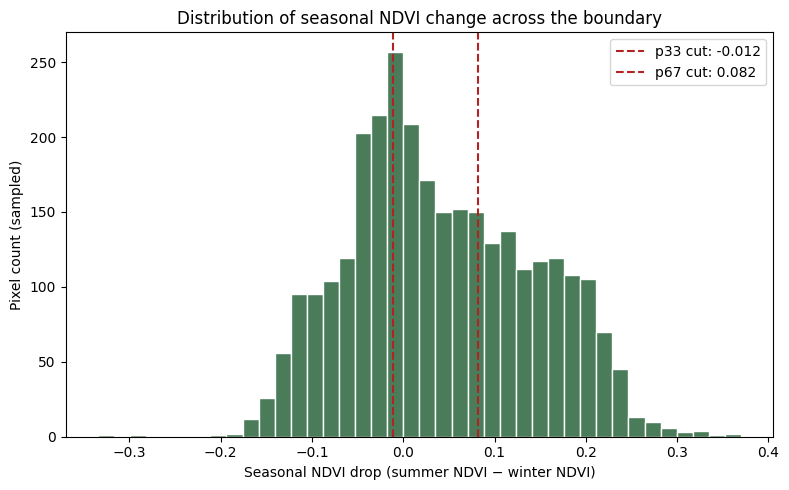

In [45]:
import matplotlib.pyplot as plt

sample_pts = seasonal_diff.sample(
    region=boundary_ee,
    scale=10,
    numPixels=3000,
    seed=RANDOM_SEED,
    geometries=False,
)
seasonal_diff_values = sample_pts.aggregate_array("seasonal_diff").getInfo()
print(f"Sampled {len(seasonal_diff_values)} pixel values.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(seasonal_diff_values, bins=40, color="#4a7c59", edgecolor="white")
for b, lbl in zip(breaks, ["p33 cut", "p67 cut"]):
    ax.axvline(b, color="firebrick", linestyle="--", linewidth=1.5, label=f"{lbl}: {b:.3f}")
ax.set_xlabel("Seasonal NDVI drop (summer NDVI − winter NDVI)")
ax.set_ylabel("Pixel count (sampled)")
ax.set_title("Distribution of seasonal NDVI change across the boundary")
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
import geemap

strata_palette = ["#f4d35e", "#8fbc5a", "#1e5631"][:NUM_STRATA]

Map = geemap.Map()
Map.centerObject(boundary_ee, zoom=14)
Map.add_basemap("SATELLITE")

Map.addLayer(
    seasonal_diff, {"min": -0.05, "max": 0.15, "palette": ["blue", "white", "orange"]},
    "Seasonal NDVI diff (continuous)"
)
Map.addLayer(
    strata_img, {"min": 0, "max": NUM_STRATA - 1, "palette": strata_palette},
    "Strata (from seasonal diff)"
)
Map.addLayer(
    ee.Image().paint(ee.FeatureCollection([ee.Feature(boundary_ee)]), 0, 3),
    {"palette": "black"}, "Boundary"
)
Map.add_legend(title="Stratum", keys=strata_labels, colors=strata_palette)
Map

Map(center=[45.57213595496022, -122.77154791671418], controls=(WidgetControl(options=['position', 'transparent…

In [47]:
import geopandas as gpd
from shapely.geometry import Point

def generate_stratified_points(strata_image, boundary_geom_ee, allocation, min_spacing_ft, seed):
    """Generate min-spacing-filtered random points within each stratum."""
    all_points = []
    min_spacing_m = min_spacing_ft * 0.3048
    rng = np.random.default_rng(seed)

    for stratum_id, n_plots in enumerate(allocation):
        if n_plots == 0:
            continue
        stratum_mask = strata_image.eq(stratum_id).selfMask()
        candidates = stratum_mask.sample(
            region=boundary_geom_ee,
            scale=10,
            numPixels=int(n_plots * 40),
            seed=int(seed) + stratum_id,
            geometries=True,
        )
        coords = candidates.geometry().coordinates().getInfo()
        cand_pts = [Point(c[0], c[1]) for c in coords]
        rng.shuffle(cand_pts)

        cand_gdf = gpd.GeoDataFrame(geometry=cand_pts, crs=4326).to_crs(epsg=5070)
        chosen = []
        for pt in cand_gdf.geometry:
            if all(pt.distance(c) >= min_spacing_m for c in chosen):
                chosen.append(pt)
            if len(chosen) >= n_plots:
                break

        if len(chosen) < n_plots:
            print(f"  Warning: stratum {stratum_id} only found {len(chosen)}/{n_plots} "
                  f"plots meeting the {min_spacing_ft} ft spacing rule.")

        chosen_wgs84 = gpd.GeoSeries(chosen, crs=5070).to_crs(epsg=4326)
        for pt in chosen_wgs84:
            all_points.append({"stratum": stratum_id, "lon": pt.x, "lat": pt.y})

    return pd.DataFrame(all_points)

Loaded 2558 trail segment(s) citywide.
Clipped to 268 trail segment(s) within the boundary.
Reachable zone (within 150 ft of a trail): 2,251.2 acres (44.0% of the boundary)


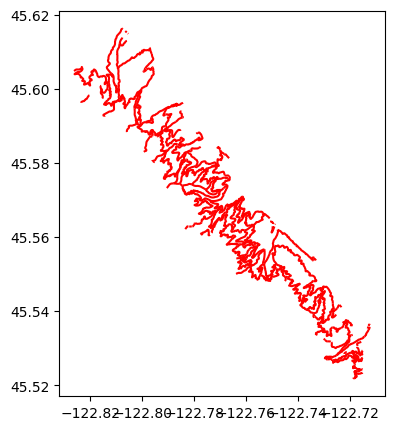

In [48]:
TRAILS_SHAPEFILE = "/Users/colelacroix/Downloads/Parks_Trails/Parks_Trails.shp"
MAX_DISTANCE_FROM_TRAIL_FT = 150

trails_gdf = gpd.read_file(TRAILS_SHAPEFILE)
if trails_gdf.crs is None:
    raise ValueError("Trails file has no CRS defined.")
trails_gdf = trails_gdf.to_crs(epsg=4326)
print(f"Loaded {len(trails_gdf)} trail segment(s) citywide.")

trails_gdf = gpd.clip(trails_gdf, boundary_gdf)
print(f"Clipped to {len(trails_gdf)} trail segment(s) within the boundary.")
trails_gdf.plot(figsize=(5, 5), color="red")

# Buffer trails in an equal-distance CRS, then clip to the boundary
max_distance_m = MAX_DISTANCE_FROM_TRAIL_FT * 0.3048
trail_buffer_5070 = trails_gdf.to_crs(epsg=5070).geometry.buffer(max_distance_m).union_all()
boundary_5070 = boundary_gdf.to_crs(epsg=5070).geometry.union_all()
reachable_zone_5070 = trail_buffer_5070.intersection(boundary_5070)

reachable_zone_gdf = gpd.GeoSeries([reachable_zone_5070], crs=5070).to_crs(epsg=4326)
reachable_zone_ee = ee.Geometry(mapping(reachable_zone_gdf.iloc[0]))

reachable_acres = reachable_zone_5070.area / 4046.8564224
reachable_pct = 100 * reachable_zone_5070.area / boundary_5070.area
print(f"Reachable zone (within {MAX_DISTANCE_FROM_TRAIL_FT} ft of a trail): "
      f"{reachable_acres:,.1f} acres ({reachable_pct:.1f}% of the boundary)")

In [49]:
stratum_masks = ee.Image.cat([
    strata_img.eq(i).rename(f"stratum_{i}") for i in range(NUM_STRATA)
])
area_by_stratum = stratum_masks.multiply(ee.Image.pixelArea())

stratum_areas_dict = area_by_stratum.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=reachable_zone_ee,   # <-- changed from boundary_ee
    scale=10,
    maxPixels=1e9,
    bestEffort=True,
).getInfo()

stratum_areas_m2 = np.array([stratum_areas_dict[f"stratum_{i}"] for i in range(NUM_STRATA)])
stratum_areas_acres = stratum_areas_m2 / 4046.8564224
total_area_acres = stratum_areas_acres.sum()

# --- Allocate plot counts proportional to area, min 3 per stratum ---
MIN_PLOTS_PER_STRATUM = 3
raw_alloc = TOTAL_PLOTS * stratum_areas_acres / total_area_acres
alloc = np.maximum(np.round(raw_alloc).astype(int), MIN_PLOTS_PER_STRATUM)
while alloc.sum() > TOTAL_PLOTS:
    i = np.argmax(alloc - MIN_PLOTS_PER_STRATUM)
    if alloc[i] > MIN_PLOTS_PER_STRATUM:
        alloc[i] -= 1
    else:
        break
while alloc.sum() < TOTAL_PLOTS:
    alloc[np.argmax(stratum_areas_acres)] += 1

alloc_df = pd.DataFrame({
    "stratum": range(NUM_STRATA),
    "label": strata_labels,
    "area_acres": stratum_areas_acres.round(2),
    "pct_of_boundary": (100 * stratum_areas_acres / total_area_acres).round(1),
    "plots_allocated": alloc,
})
print(f"Total boundary area: {total_area_acres:,.1f} acres")
alloc_df

Total boundary area: 2,250.8 acres


,stratum,label,area_acres,pct_of_boundary,plots_allocated
0,0,Stratum 1 (low seasonal change — likely evergr...,780.47,34.7,10
1,1,Stratum 2 (moderate seasonal change — likely m...,717.74,31.9,10
2,2,Stratum 3 (high seasonal change — likely decid...,752.62,33.4,10


In [50]:
plots_df = generate_stratified_points(
    strata_img, reachable_zone_ee,   # <-- changed from boundary_ee
    alloc_df["plots_allocated"].values,
    MIN_PLOT_SPACING_FT, RANDOM_SEED,
)
plots_df.insert(0, "plot_id", [f"P{str(i+1).zfill(3)}" for i in range(len(plots_df))])
plots_df = plots_df.merge(alloc_df[["stratum", "label"]], on="stratum", how="left")

print(f"Placed {len(plots_df)} plots across {NUM_STRATA} strata, all within {MAX_DISTANCE_FROM_TRAIL_FT} ft of a trail.")
plots_df

Placed 30 plots across 3 strata, all within 150 ft of a trail.


,plot_id,stratum,lon,lat,label
0,P001,0,-122.814693,45.595460,Stratum 1 (low seasonal change — likely evergr...
1,P002,0,-122.785375,45.579539,Stratum 1 (low seasonal change — likely evergr...
2,P003,0,-122.781358,45.583601,Stratum 1 (low seasonal change — likely evergr...
3,P004,0,-122.802246,45.609049,Stratum 1 (low seasonal change — likely evergr...
4,P005,0,-122.805806,45.607730,Stratum 1 (low seasonal change — likely evergr...
5,P006,0,-122.809848,45.601080,Stratum 1 (low seasonal change — likely evergr...
6,P007,0,-122.779307,45.576667,Stratum 1 (low seasonal change — likely evergr...
7,P008,0,-122.762915,45.568058,Stratum 1 (low seasonal change — likely evergr...
8,P009,0,-122.786199,45.580703,Stratum 1 (low seasonal change — likely evergr...
9,P010,0,-122.765695,45.569162,Stratum 1 (low seasonal change — likely evergr...


In [51]:
from ipywidgets import HTML

strata_palette = ["#f4d35e", "#8fbc5a", "#1e5631"][:NUM_STRATA]

Map = geemap.Map()
Map.centerObject(boundary_ee, zoom=14)
Map.add_basemap("SATELLITE")

Map.addLayer(
    strata_img, {"min": 0, "max": NUM_STRATA - 1, "palette": strata_palette},
    "Strata (from seasonal diff)"
)
Map.addLayer(
    ee.Image().paint(ee.FeatureCollection([ee.Feature(boundary_ee)]), 0, 3),
    {"palette": "black"}, "Boundary"
)
Map.addLayer(
    ee.Image().paint(ee.FeatureCollection([ee.Feature(reachable_zone_ee)]), 0, 2),
    {"palette": "cyan"}, "Reachable zone (near trails)"
)
Map.add_gdf(trails_gdf, layer_name="Trails", style={"color": "red", "weight": 2})

for _, row in plots_df.iterrows():
    Map.add_marker(
        location=(row["lat"], row["lon"]),
        popup=HTML(value=f"{row['plot_id']} — {row['label']}"),
    )

Map.add_legend(title="Stratum", keys=strata_labels, colors=strata_palette)
Map

Map(center=[45.572135954961084, -122.7715479167134], controls=(WidgetControl(options=['position', 'transparent…

In [57]:
import simplekml

kml = simplekml.Kml()

# Distinct pin color per stratum so you can tell them apart at a glance in the field
stratum_colors = {
    0: simplekml.Color.yellow,
    1: simplekml.Color.green,
    2: simplekml.Color.darkgreen,
}

for _, row in plots_df.iterrows():
    pnt = kml.newpoint(
        name=row["plot_id"],
        description=f"Stratum: {row['label']}",
        coords=[(row["lon"], row["lat"])],
    )
    pnt.style.iconstyle.color = stratum_colors.get(row["stratum"], simplekml.Color.white)
    pnt.style.iconstyle.icon.href = "http://maps.google.com/mapfiles/kml/paddle/wht-blank.png"

kml.save("plot_locations.kml")
print(f"Saved plot_locations.kml with {len(plots_df)} plots.")

Saved plot_locations.kml with 30 plots.
